In [169]:
import numpy as np
from xrd_simulator.beam import Beam


# The beam of xrays is represented as a convex polyhedron
# We specify the vertices in a numpy array.

beam_half_edgewidth = 500.0

beam_vertices = np.array(
   [
      [-1e6, -beam_half_edgewidth, -beam_half_edgewidth],
      [-1e6, beam_half_edgewidth, -beam_half_edgewidth],
      [-1e6, beam_half_edgewidth, beam_half_edgewidth],
      [-1e6, -beam_half_edgewidth, beam_half_edgewidth],
      [1e6, -beam_half_edgewidth, -beam_half_edgewidth],
      [1e6, beam_half_edgewidth, -beam_half_edgewidth],
      [1e6, beam_half_edgewidth, beam_half_edgewidth],
      [1e6, -beam_half_edgewidth, beam_half_edgewidth],
   ]
)

beam = Beam(
   beam_vertices,
   xray_propagation_direction=np.array([1.0, 0.0, 0.0]),
   wavelength=0.28523,
   polarization_vector=np.array([0.0, 1.0, 0.0]),
)

In [170]:
from xrd_simulator.mesh import TetraMesh


tetrahedron_bbox_size = 100.0

tetr_vertexes = np.array(
    [[tetrahedron_bbox_size, tetrahedron_bbox_size, tetrahedron_bbox_size,],
     [tetrahedron_bbox_size, -tetrahedron_bbox_size, -tetrahedron_bbox_size,],
     [-tetrahedron_bbox_size, tetrahedron_bbox_size, -tetrahedron_bbox_size,],
     [-tetrahedron_bbox_size, -tetrahedron_bbox_size, tetrahedron_bbox_size,],
     ]
)

# xrd_simulator supports several ways to generate a mesh, here we
# generate meshed solid sphere using a level set.
mesh = TetraMesh.generate_mesh_from_vertices(
    tetr_vertexes, np.arange(4)[None, :],
)


from xrd_simulator.phase import Phase
quartz = Phase(
   unit_cell=[4.926, 4.926, 5.4189, 90.0, 90.0, 120.0],
   sgname="P3221",  # (Quartz)
   path_to_cif_file="quartz.cif",  # phases can be defined from crystalographic information files
)

cs_cl = Phase(
   unit_cell=[4.994, 4.994, 4.994, 90.0, 90.0, 90.0],
   sgname="F432",  # (Quartz)
   path_to_cif_file="CsCl.cif",  # phases can be defined from crystalographic information files
)



from scipy.spatial.transform import Rotation as R
from xrd_simulator.polycrystal import Polycrystal

orientation = R.random(mesh.number_of_elements).as_matrix()
# element_phase_map assigns each mesh element to a phase (0 = first phase)
element_phase_map = np.zeros(mesh.number_of_elements, dtype=int)
polycrystal = Polycrystal(
   mesh,
   orientation,
   strain=np.zeros((3, 3)),
   phases=quartz,
   element_phase_map=element_phase_map,
)

In [171]:
from xfab.tools import form_b_mat, genhkl_unique, tth



from xrd_simulator.motion import RigidBodyMotion
from xfab.tools import form_b_mat
def align_grain(polycrystal, grainindex, beam,  hkl_tuple, eta, ):

   phase_index = int(polycrystal.element_phase_map[grainindex])
   phase = polycrystal.phases[phase_index]

   B = form_b_mat(phase.unit_cell)
   
   q = np.array(polycrystal.orientation_lab[0]) @ B @ hkl_tuple
   theta = np.arcsin(beam.wavelength * np.linalg.norm(q) / 4 / np.pi)
   target_orientation = np.array([-np.sin(theta), np.cos(theta)*np.cos(eta), np.cos(theta)*np.sin(eta)])
   current_orientation = q / np.linalg.norm(q)

   rotation_to_x = R.from_euler('zx',
                              (np.arctan2(np.sqrt(current_orientation[1]**2 +current_orientation[2]**2, ), current_orientation[0]),
                                 np.arctan2(current_orientation[2], current_orientation[1]),)).inv()
   rotation_to_target = R.from_euler('zx',
                              (np.arctan2(np.sqrt(target_orientation[1]**2 +target_orientation[2]**2, ), target_orientation[0]),
                                 np.arctan2(target_orientation[2], target_orientation[1]),))

   total_rotation = (rotation_to_target*rotation_to_x)
   rot_angle = total_rotation.magnitude()
   rot_axis = total_rotation.as_rotvec() / rot_angle

   alignment_rotation = RigidBodyMotion(
      rotation_axis=rot_axis,
      rotation_angle=rot_angle,
      translation=np.array([0.0, 0.0, 0.0]),
   )

   polycrystal.transform(alignment_rotation, 1.0)
   return alignment_rotation
   


# genhkl_unique(quartz.unit_cell, 0.3, 0.4, quartz.sgname)

# B = 2 * np.pi * np.linalg.inv(np.array([[quartz.unit_cell[0], 0, 0,],
#                           [np.cos(np.pi*2/3) * quartz.unit_cell[0], np.sin(np.pi*2/3) * quartz.unit_cell[0], 0.0],
#                           [0, 0, quartz.unit_cell[2]]]))




# print(tth(quartz.unit_cell, hkl_tuple, beam.wavelength)*180/np.pi/2)


### Choose a hkl to measure and bring it into alignment at a chose eta angle
eta = 0.0
hkl_tuple = (2, 1, 0)

alignment_rotation = align_grain(polycrystal, 0, beam, hkl_tuple, eta)






/tmp/ipykernel_347305/3586176883.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  q = np.array(polycrystal.orientation_lab[0]) @ B @ hkl_tuple


In [172]:

phase_index = int(polycrystal.element_phase_map[0])
phase = polycrystal.phases[phase_index]
B = form_b_mat(phase.unit_cell)
q = np.array(polycrystal.orientation_lab[0]) @ B @ hkl_tuple
theta = np.arcsin(beam.wavelength * np.linalg.norm(q) / 4 / np.pi)

print(q)
print(-np.arctan2(q[0], q[1]))
print(theta)


[-0.34466171  3.88148942  0.        ]
0.08856396927526022
0.08856396927526015


/tmp/ipykernel_347305/3542781502.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  q = np.array(polycrystal.orientation_lab[0]) @ B @ hkl_tuple


In [173]:


from xrd_simulator.detector import Detector

detector_distance = 1e6
pixelsize =  1.0
n_pixels = 512


detetctor_halfsize = n_pixels * pixelsize / 2
detector_mid = np.array([detector_distance, detector_distance*np.tan(2*theta)*np.cos(eta), detector_distance*np.tan(2*theta)*np.sin(eta)])

# The detector plane is defined by it's corner coordinates det_corner_0,det_corner_1,det_corner_2
detector = Detector(
   det_corner_0=detector_mid + np.array([0.0, -1.0, -1.0])*detetctor_halfsize, 
   det_corner_1=detector_mid + np.array([0.0, 1.0, -1.0])*detetctor_halfsize,
   det_corner_2=detector_mid + np.array([0.0, -1.0, 1.0])*detetctor_halfsize,
   pixel_size=(pixelsize, pixelsize),
   gaussian_sigma=1.0,
   max_gaussian_kernel_radius=5,
)


In [174]:

rocking_axis = np.array([0, 0, 1])
rocking_angle = 5.0 * np.pi / 180

motion_rock_init = RigidBodyMotion(
   rotation_axis= -rocking_axis,
   rotation_angle= 0.5 * rocking_angle,
   translation=np.array([0.0, 0.0, 0.0]),
)

motion_rock = RigidBodyMotion(
   rotation_axis=rocking_axis,
   rotation_angle= rocking_angle,
   translation=np.array([0.0, 0.0, 0.0]),
)

motion_rock_reset = RigidBodyMotion(
   rotation_axis=rocking_axis,
   rotation_angle= 0.5 * rocking_angle,
   translation=np.array([0.0, 0.0, 0.0]),
)

polycrystal.transform(motion_rock_init, 1.0)

peaks_dict = polycrystal.diffract(beam, motion_rock, detector=detector)


diffraction_pattern, peaks_dict = detector.render(
   peaks_dict, frames_to_render=0, method="macro"
)

polycrystal.transform(motion_rock_reset, 1.0)



[Detector.render] frames_to_render < 1, setting to 1
[Macro] Peak 1/1                                        |████████████████████████████████████████| 100.0%


In [175]:
pattern = (
   diffraction_pattern[0].cpu().numpy()
   if hasattr(diffraction_pattern, "cpu")
   else diffraction_pattern[0]
)

In [176]:
from xrd_simulator.gaussian_crystal_model import GaussianGrainish, GaussianPolycrystal
import torch

def make_random_tensor(axis_1, axis_2):
    random_direction = np.random.normal(size=3)
    random_direction = random_direction/np.linalg.norm(random_direction)
    tensor = axis_1**2 * np.eye(3) + (axis_2**2-axis_1**2) * np.outer(random_direction, random_direction)
    return tensor


misorientation_tensor = make_random_tensor(
    np.random.uniform(0.0001, 0.0001),
    np.random.uniform(0.0001, 0.0001),
)

# grain_list = []
# for vert in tetr_vertexes:

#     grain = GaussianGrainish(
#             phase=quartz, #  For now it assumes all gaussians are the same phase, but it just needs a wrapper for multiphase
#             position=vert*0.5, # 3 vector centroid real-space position
#             shape_tensor=tetrahedron_bbox_size**2*np.eye(3)/4, # 3-by-3 symmetric shape tensor where the eigenvalues are the radii-squared.
#             orientation=orientation[0], # 3-by-3 rotation matrix.
#             misorientation_tensor=misorientation_tensor, # 3-by-3 misorientation tensor where the eigenvalues are the misorientaion spread in radians squared.
#                                                             # misorientation vectors live in laboratory coordinates.
#             strain_tensor=polycrystal.strain_lab[0] # 3-by-3 symmetric strain tensor.
#         )
#     grain_list.append(grain)
# grain = GaussianGrainish(
#         phase=quartz, #  For now it assumes all gaussians are the same phase, but it just needs a wrapper for multiphase
#         position=vert*0.0, # 3 vector centroid real-space position
#         shape_tensor=tetrahedron_bbox_size**2*np.eye(3)/4, # 3-by-3 symmetric shape tensor where the eigenvalues are the radii-squared.
#         orientation=orientation[0], # 3-by-3 rotation matrix.
#         misorientation_tensor=misorientation_tensor, # 3-by-3 misorientation tensor where the eigenvalues are the misorientaion spread in radians squared.
#                                                         # misorientation vectors live in laboratory coordinates.
#         strain_tensor=polycrystal.strain_lab[0] # 3-by-3 symmetric strain tensor.
#     )
# grain_list.append(grain)

grain_list = []
for vert1 in tetr_vertexes:
    for vert2 in tetr_vertexes:
        if np.allclose(vert1, vert2):
            continue

        grain = GaussianGrainish(
                phase=quartz, #  For now it assumes all gaussians are the same phase, but it just needs a wrapper for multiphase
                position=0.3*(vert1+vert2), # 3 vector centroid real-space position
                shape_tensor=tetrahedron_bbox_size**2*np.eye(3)/8 + np.outer(vert1-vert2, vert1-vert2)/8, # 3-by-3 symmetric shape tensor where the eigenvalues are the radii-squared.
                orientation=orientation[0], # 3-by-3 rotation matrix.
                misorientation_tensor=misorientation_tensor, # 3-by-3 misorientation tensor where the eigenvalues are the misorientaion spread in radians squared.
                                                                # misorientation vectors live in laboratory coordinates.
                strain_tensor=polycrystal.strain_lab[0] # 3-by-3 symmetric strain tensor.
            )
        grain_list.append(grain)

grain = GaussianGrainish(
        phase=quartz, #  For now it assumes all gaussians are the same phase, but it just needs a wrapper for multiphase
        position=vert*0.0, # 3 vector centroid real-space position
        shape_tensor=tetrahedron_bbox_size**2*np.eye(3)/2, # 3-by-3 symmetric shape tensor where the eigenvalues are the radii-squared.
        orientation=orientation[0], # 3-by-3 rotation matrix.
        misorientation_tensor=misorientation_tensor, # 3-by-3 misorientation tensor where the eigenvalues are the misorientaion spread in radians squared.
                                                        # misorientation vectors live in laboratory coordinates.
        strain_tensor=polycrystal.strain_lab[0] # 3-by-3 symmetric strain tensor.
    )
grain_list.append(grain)

gauss_polycrystal = GaussianPolycrystal(grain_list)



In [177]:
from xrd_simulator.beam import GaussianBeam

gaussian_beam = GaussianBeam(
    xray_propagation_direction=np.array([1.0, 0.0, 0.0]),
    beam_centroid_position=np.array([0.0, 0.0, 0.0,]),
    wavelength=beam.wavelength,
    long_axis_width = beam_half_edgewidth*100,
)

In [178]:
gauss_polycrystal.transform(alignment_rotation)

f = gauss_polycrystal.render_detector_frame(
    beam=gaussian_beam,
    detector=detector,
    sample_rotation_during_exposure = rocking_axis * rocking_angle,
    timing=True,
)




Bragg-condition filterin took 0.02272486686706543
Reciprocal space part took 0.00467681884765625
Realspace proj took 0.0009109973907470703
Raytracing took 0.001947641372680664
Rasterization took 1.4166960716247559


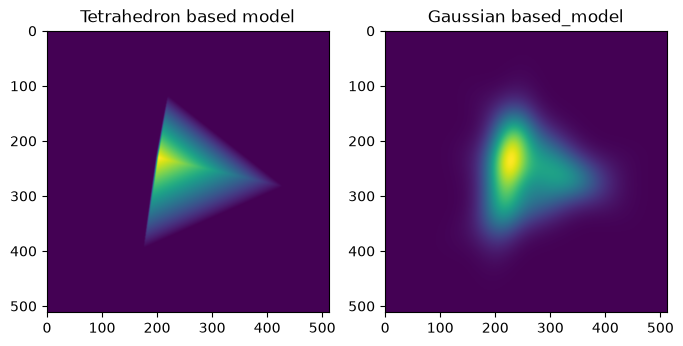

In [179]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
# render returns (frames, height, width), take first frame

img = axs[0].imshow(pattern)
axs[0].set_title('Tetrahedron based model')

img = axs[1].imshow(f)
axs[1].set_title('Gaussian based_model')
plt.show()
